In [1]:
import tensorflow as tf
from sklearn.datasets import make_circles
n_samples = 1000
X, y = make_circles(n_samples,noise=0.03,random_state=42)

In [2]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [3]:
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

In [4]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:, 0], "X1":X[:, 1], "label":y})
circles.head()

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [5]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

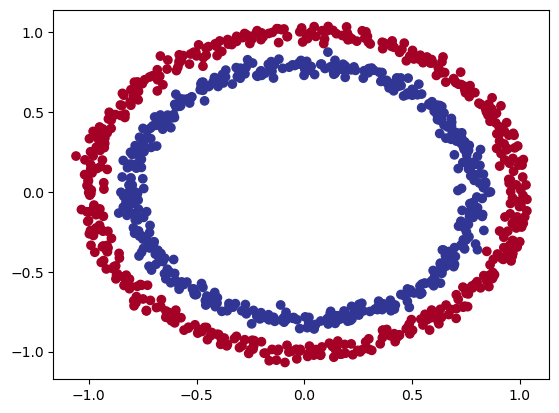

In [6]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

In [7]:
X.shape, y.shape

((1000, 2), (1000,))

In [8]:
len(X), len(y)
X[0], y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

In [9]:
tf.random.set_seed(42)
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(), optimizer=tf.keras.optimizers.SGD(),metrics=['accuracy'])
model_1.fit(X, y, epochs=3)

Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4790 - loss: 3.7696
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4980 - loss: 0.8714 
Epoch 3/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4960 - loss: 0.7181 


In [10]:
model_1.fit(X, y, epochs=3, verbose=0) 
model_1.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4870 - loss: 0.6935


[0.6934924125671387, 0.4869999885559082]

In [11]:
tf.random.set_seed(42)
model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(1), 
  tf.keras.layers.Dense(1)
])
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['accuracy'])
model_2.fit(X, y, epochs=3, verbose=0)

In [12]:
model_2.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5100 - loss: 3.1028  


[3.1027824878692627, 0.5099999904632568]

In [13]:
tf.random.set_seed(42)
model_3 = tf.keras.Sequential([
  tf.keras.layers.Dense(100), 
  tf.keras.layers.Dense(10), 
  tf.keras.layers.Dense(1)
])
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),optimizer=tf.keras.optimizers.Adam(), metrics=['accuracy'])
model_3.fit(X, y, epochs=3, verbose=1) 

Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4570 - loss: 2.8605
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 0.7235
Epoch 3/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4450 - loss: 0.6972


Creating Random Tensor

In [14]:
# If seed is same then tensor will generate same random it check if it is generated before or not
random1 = tf.random.Generator.from_seed(42)
random2 = tf.random.Generator.from_seed(42)
random1 = random1.normal(shape=(3,3))
random1 = tf.random.shuffle(random1)
random2 = random2.normal(shape=(3,3))
random1,random2,random1==random2

(<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
 array([[-1.2573844 , -0.23193763, -1.8107855 ],
        [ 0.09988727, -0.50998646, -0.7535805 ],
        [-0.7565803 , -0.06854702,  0.07595026]], dtype=float32)>,
 <tf.Tensor: shape=(3, 3), dtype=float32, numpy=
 array([[-0.7565803 , -0.06854702,  0.07595026],
        [-1.2573844 , -0.23193763, -1.8107855 ],
        [ 0.09988727, -0.50998646, -0.7535805 ]], dtype=float32)>,
 <tf.Tensor: shape=(3, 3), dtype=bool, numpy=
 array([[False, False, False],
        [False, False, False],
        [False, False, False]])>)

In [15]:
# Convert numpy array into a tensor
import numpy as np
arr = np.arange(1,25,dtype=np.int32)
arr

tensor = tf.constant(arr)
tensor

<tf.Tensor: shape=(24,), dtype=int32, numpy=
array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24], dtype=int32)>

In [16]:
t = tf.zeros(shape=(2,3,4,5))
t

<tf.Tensor: shape=(2, 3, 4, 5), dtype=float32, numpy=
array([[[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]],


       [[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]]], dtype=float32)>

In [17]:
t.shape,t.ndim,tf.size(t)

(TensorShape([2, 3, 4, 5]), 4, <tf.Tensor: shape=(), dtype=int32, numpy=120>)

In [18]:
t1 = tf.constant([[1,2,3],[1,2,3]])
t1.shape

TensorShape([2, 3])

In [19]:
#adding a new dimension
t1_new = t1[...,tf.newaxis]
t1_new.ndim
t1_new

<tf.Tensor: shape=(2, 3, 1), dtype=int32, numpy=
array([[[1],
        [2],
        [3]],

       [[1],
        [2],
        [3]]], dtype=int32)>

In [20]:
# it does not add to original array
t1+10
t1-1
tf.multiply(t1,10)

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[10, 20, 30],
       [10, 20, 30]], dtype=int32)>

In [21]:
t2 = tf.constant([[1,2,],[4,5,]])
tf.matmul(t2,t2)
#multiplication
t2@t2
t2*t2 #multiply with itself

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 1,  4],
       [16, 25]], dtype=int32)>

In [22]:
#datatype conversion
data = tf.constant([[1.2,2],[2,3]])
data.dtype #float32
data_1 = tf.cast(data,dtype=tf.float16) #converts into float 16 (reduced precision)
data_1

<tf.Tensor: shape=(2, 2), dtype=float16, numpy=
array([[1.2, 2. ],
       [2. , 3. ]], dtype=float16)>

In [23]:
#Aggregations
t3 = tf.constant(np.random.randint(0,100,size=50))
print(tf.reduce_max(t3))
print(tf.reduce_mean(t3))
print(tf.reduce_sum(t3))


tf.Tensor(99, shape=(), dtype=int32)
tf.Tensor(51, shape=(), dtype=int32)
tf.Tensor(2584, shape=(), dtype=int32)


tf.float32

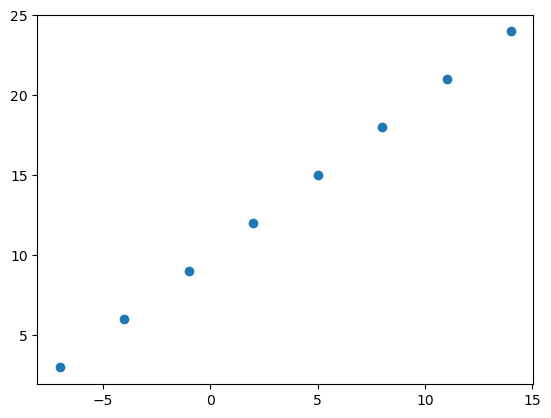

In [24]:
import numpy as np
import matplotlib.pyplot as plt
x = tf.constant([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])
y = tf.constant([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])
plt.scatter(x,y)
x.dtype

In [25]:
tf.random.set_seed(42)
model = tf.keras.Sequential([tf.keras.layers.Dense(1)])
model.compile(loss=tf.keras.losses.mae,
             optimizer=tf.keras.optimizers.SGD(),
             metrics=["mae"])
model.fit(tf.expand_dims(x,axis=-1),y,epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 914ms/step - loss: 20.9267 - mae: 20.9267
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 20.5466 - mae: 20.5466
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 20.2653 - mae: 20.2653
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 19.9841 - mae: 19.9841
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 19.7028 - mae: 19.7028
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 19.4216 - mae: 19.4216
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 19.1403 - mae: 19.1403
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 18.8591 - mae: 18.8591
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 18.5778 - mae: 18.5778
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 18.2966 - mae: 18.2966


In [26]:
x,y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [27]:
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


array([[-17.153181]], dtype=float32)

In [28]:
X = np.arange(-100, 100, 4)
X

array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96])

In [29]:
y = np.arange(-90, 110, 4)
y

array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])

In [30]:
len(X)

50

In [31]:
X_train = X[:40] 
y_train = y[:40]
X_test = X[40:] 
y_test = y[40:]
len(X_train), len(X_test)

(40, 10)

In [32]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(1)
])
model.compile(loss=tf.keras.losses.mae,optimizer=tf.keras.optimizers.SGD(),metrics=["mae"])

In [33]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.fit(X_train, y_train, epochs=100, verbose=0)

In [35]:
y_preds = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


In [36]:
y_preds

array([[57.741825],
       [61.499447],
       [65.25707 ],
       [69.014694],
       [72.772316],
       [76.52994 ],
       [80.28756 ],
       [84.04518 ],
       [87.8028  ],
       [91.560425]], dtype=float32)

In [37]:
def plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=y_preds):
  plt.figure(figsize=(10, 7))
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  plt.scatter(test_data, predictions, c="r", label="Predictions")
  plt.legend();

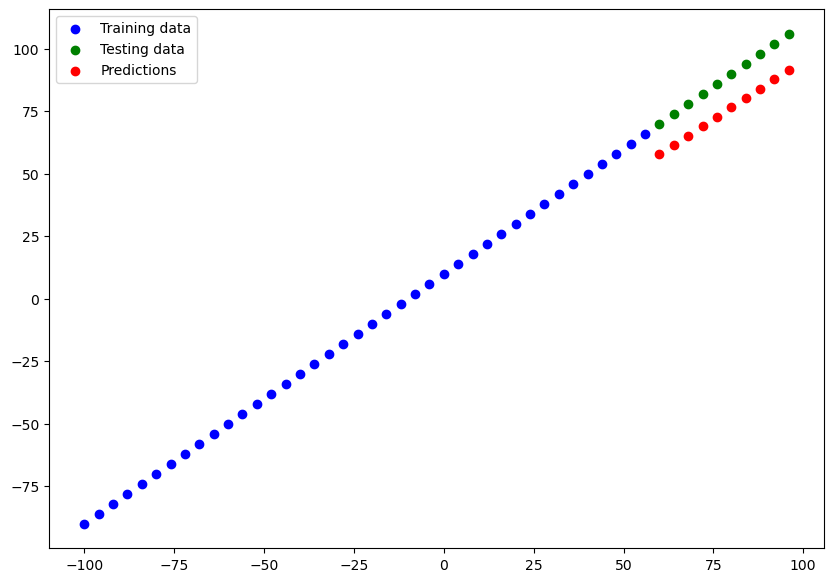

In [38]:
plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=y_preds)


In [39]:
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - loss: 13.3489 - mae: 13.3489


[13.34887409210205, 13.34887409210205]

In [40]:
mae_fn = tf.keras.losses.MeanAbsoluteError()
mae = mae_fn(y_test, y_preds).numpy()
mae

np.float32(13.348874)

In [41]:
y_test

array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106])

In [42]:
y_preds

array([[57.741825],
       [61.499447],
       [65.25707 ],
       [69.014694],
       [72.772316],
       [76.52994 ],
       [80.28756 ],
       [84.04518 ],
       [87.8028  ],
       [91.560425]], dtype=float32)

In [48]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

In [49]:
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")

In [50]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [53]:
insurance_one_hot = pd.get_dummies(insurance).astype(int)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,1,0,0,1,0,0,0,1
1,18,33,1,1725,0,1,1,0,0,0,1,0
2,28,33,3,4449,0,1,1,0,0,0,1,0
3,33,22,0,21984,0,1,1,0,0,1,0,0
4,32,28,0,3866,0,1,1,0,0,1,0,0


In [54]:
X = insurance_one_hot.drop("charges", axis=1)
y = insurance_one_hot["charges"]

In [55]:
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27,0,1,0,0,1,0,0,0,1
1,18,33,1,0,1,1,0,0,0,1,0
2,28,33,3,0,1,1,0,0,0,1,0
3,33,22,0,0,1,1,0,0,1,0,0
4,32,28,0,0,1,1,0,0,1,0,0


In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
tf.random.set_seed(42)

insurance_model = tf.keras.Sequential([
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1)
])

insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.SGD(),
                        metrics=['mae'])

insurance_model.fit(X_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9004.0713 - mae: 9004.0713     
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7595.9146 - mae: 7595.9146 
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7549.2671 - mae: 7549.2671 
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7482.4092 - mae: 7482.4092 
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7552.3345 - mae: 7552.3345
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7520.5537 - mae: 7520.5537 
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7676.5005 - mae: 7676.5005 
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7507.1265 - mae: 7507.1265 
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7529.3579 - mae: 7529.3579 
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7811.8555 - mae: 7811.8555 
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7647.5215 - mae: 7647.5215
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━

In [69]:
insurance_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7976.6099 - mae: 7976.6099 


[7976.60986328125, 7976.60986328125]

In [70]:
tf.random.set_seed(42)

insurance_model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(100), 
  tf.keras.layers.Dense(10), 
  tf.keras.layers.Dense(1) 
])

insurance_model_2.compile(loss=tf.keras.losses.mae,optimizer=tf.keras.optimizers.Adam(), metrics=['mae'])
history = insurance_model_2.fit(X_train, y_train, epochs=10, verbose=0)

In [71]:
insurance_model_2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7531.7832 - mae: 7531.7832  


[7531.783203125, 7531.783203125]

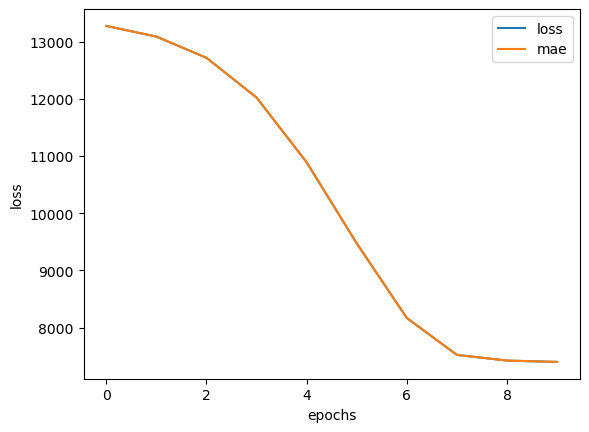

In [72]:
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs");

In [73]:
history_2 = insurance_model_2.fit(X_train, y_train, epochs=100, verbose=0)

In [74]:
insurance_model_2_loss, insurance_model_2_mae = insurance_model_2.evaluate(X_test, y_test)
insurance_model_2_loss, insurance_model_2_mae

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3922.7695 - mae: 3922.7695 


(3922.76953125, 3922.76953125)

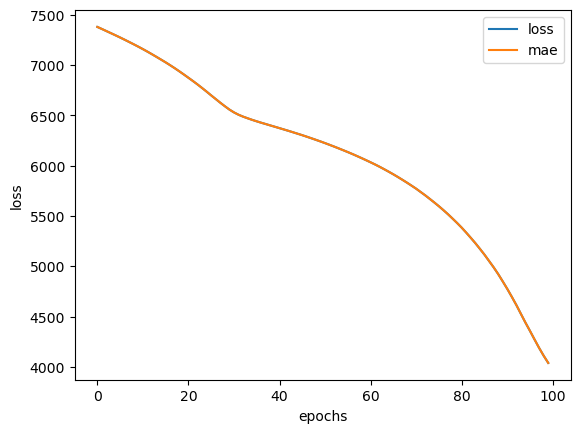

In [75]:
pd.DataFrame(history_2.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs");

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")

In [77]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [78]:

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

ct = make_column_transformer(
    (MinMaxScaler(), ["age", "bmi", "children"]), 
    (OneHotEncoder(handle_unknown="ignore"), ["sex", "smoker", "region"])
)

X = insurance.drop("charges", axis=1)
y = insurance["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ct.fit(X_train)

X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)

In [ ]:
tf.random.set_seed(42)

insurance_model_3 = tf.keras.Sequential([
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(10),
  tf.keras.layers.Dense(1)
])

insurance_model_3.compile(loss=tf.keras.losses.mae,optimizer=tf.keras.optimizers.Adam(),
            metrics=['mae'])

insurance_model_3.fit(X_train_normal, y_train, epochs=200, verbose=0) 